<a href="https://colab.research.google.com/github/Anuska111/E-Commerce-Customer-Lifetime-Value-CLV-Segmentation/blob/main/E_Commerce_Customer_Lifetime_Value_(CLV)_%26_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
##Import Required Libraries
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
##Load Dataset
df = pd.read_excel("/content/online_retail_II.xlsx")

In [9]:
##Dataset Check
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [11]:
df.shape

(525461, 8)

In [12]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [14]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [15]:
#Data Cleaning
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [16]:
df = df.dropna()

In [17]:
df.duplicated().sum()

np.int64(6771)

In [18]:
df = df.drop_duplicates()

In [19]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [20]:

df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

In [21]:
print(df[df["Invoice"].astype(str).str.startswith("C")].shape)
print(df[df["Quantity"] < 0].shape)
print(df[df["Price"] <= 0].shape)

(0, 8)
(0, 8)
(0, 8)


In [22]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [23]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [24]:
#Feature Engineering (RFM)
snapshot_date = df["InvoiceDate"].max()

In [25]:
rfm = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Revenue": "sum",
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days
}).reset_index()

In [26]:
rfm.columns = [
    "CustomerID",
    "Frequency",
    "Monetary",
    "Recency"]

In [27]:
rfm.head()

,CustomerID,Frequency,Monetary,Recency
0,12346.0,11,372.86,164
1,12347.0,2,1323.32,2
2,12348.0,1,222.16,73
3,12349.0,3,2671.14,42
4,12351.0,1,300.93,10


In [28]:
#Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

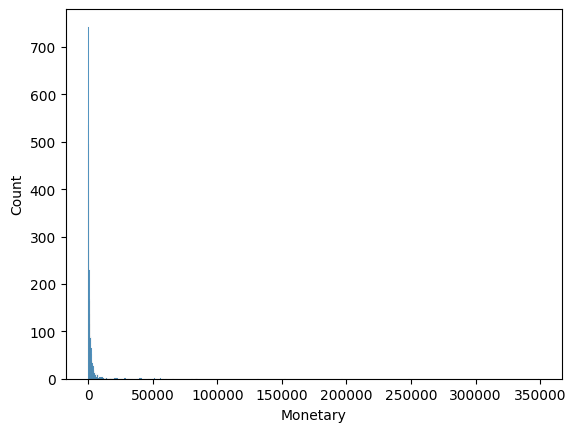

In [29]:
#Revenue Distribution
sns.histplot(rfm["Monetary"])

plt.show()

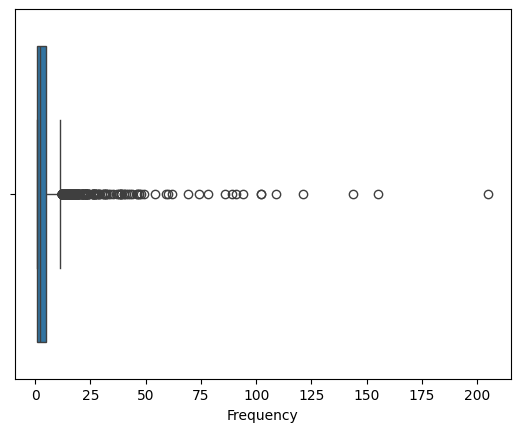

In [30]:
#Frequency Distribution
sns.boxplot(x=rfm["Frequency"])

plt.show()

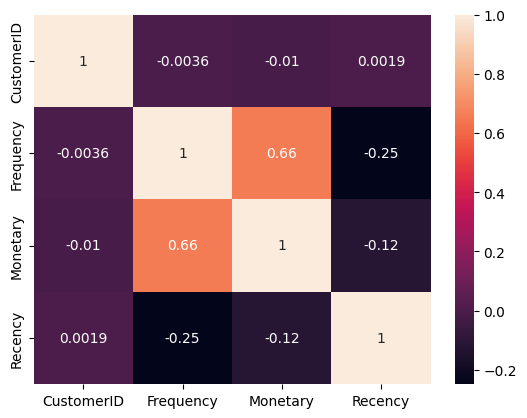

In [31]:
#Correlation
sns.heatmap(rfm.corr(), annot=True)

plt.show()

In [32]:
#Data Scaling
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(

rfm[['Recency','Frequency','Monetary']]
)

In [34]:
#Customer Segmentation
from sklearn.cluster import KMeans

In [35]:
kmeans = KMeans(
n_clusters=4,
random_state=42
)
rfm["Cluster"] = kmeans.fit_predict(
scaled_data
)

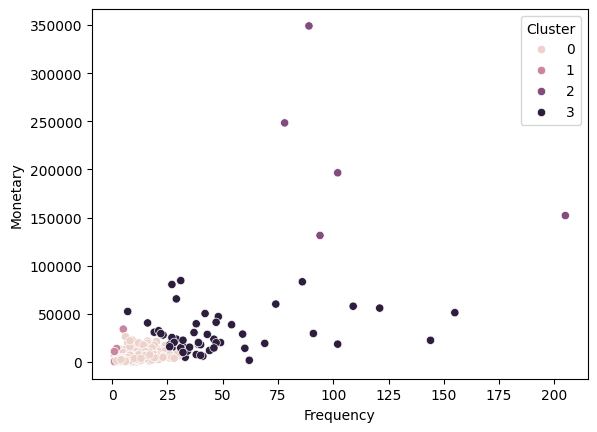

In [36]:
sns.scatterplot(
data=rfm,
x="Frequency",
y="Monetary",
hue="Cluster"
)
plt.show()

In [37]:
#Evaluate Clustering
from sklearn.metrics import silhouette_score

In [38]:
score = silhouette_score(
scaled_data,
rfm["Cluster"]
)
print(score)

0.6107948209557895


In [39]:
# Customer Segment Names

segment_names = {
    0: "At Risk Customers",
    1: "Active Customers"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(segment_names)

print(rfm[["Cluster", "CustomerSegment"]].head())

   Cluster    CustomerSegment
0        1   Active Customers
1        0  At Risk Customers
2        0  At Risk Customers
3        0  At Risk Customers
4        0  At Risk Customers


In [40]:
# Number of Customers in Each Segment

print(rfm["CustomerSegment"].value_counts())

CustomerSegment
At Risk Customers    3204
Active Customers     1047
Name: count, dtype: int64


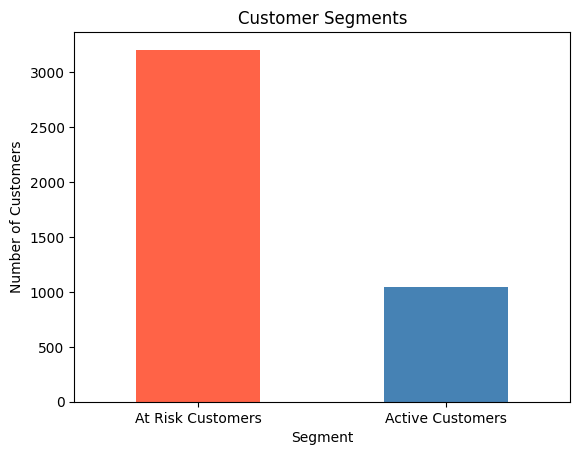

In [41]:
import matplotlib.pyplot as plt

rfm["CustomerSegment"].value_counts().plot(
    kind="bar",
    color=["tomato", "steelblue"]
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [42]:
# CREATE CLV
# Average Order Value
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

# Customer Life Span
rfm["CustomerLifeSpan"] = rfm["Recency"] + 1

# Purchase Rate
rfm["PurchaseRate"] = (
    rfm["Frequency"] / rfm["CustomerLifeSpan"])


In [43]:
# Customer Lifetime Value
rfm["CLV"] = (
    rfm["Frequency"]
    * rfm["AvgOrderValue"]
    * rfm["PurchaseRate"]
)

print(rfm[[
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "PurchaseRate",
    "CLV"
]].head())

   Recency  Frequency  Monetary  AvgOrderValue  PurchaseRate         CLV
0      164         11    372.86      33.896364      0.066667   24.857333
1        2          2   1323.32     661.660000      0.666667  882.213333
2       73          1    222.16     222.160000      0.013514    3.002162
3       42          3   2671.14     890.380000      0.069767  186.358605
4       10          1    300.93     300.930000      0.090909   27.357273


In [44]:
# REMOVE OUTLIERS
Q1 = rfm["CLV"].quantile(0.25)
Q3 = rfm["CLV"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

rfm = rfm[
    (rfm["CLV"] >= lower) &
    (rfm["CLV"] <= upper)]


In [45]:
# FEATURES & TARGET
rfm["LogFrequency"] = np.log1p(rfm["Frequency"])
rfm["LogRecency"] = np.log1p(rfm["Recency"])

X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "LogFrequency",
        "LogRecency"]]

y = rfm["CLV"]


In [46]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [47]:
# TRAIN MODEL
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)



RandomForestRegressor(n_estimators=200, random_state=42)

In [48]:
# PREDICTION
prediction = model.predict(X_test)


In [49]:
# EVALUATION
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error)
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, prediction))
r2 = r2_score(
    y_test,
    prediction)

mape = mean_absolute_percentage_error(
    y_test,
    prediction) * 100


In [50]:
print("RMSE :", rmse)
print("R2 Score :", r2)
print("MAPE :", mape)

RMSE : 24.589711529869202
R2 Score : 0.9731112868655205
MAPE : 7.448089447638644


In [51]:
print("y_test :", len(y_test))
print("prediction :", len(prediction))

y_test : 713
prediction : 713


In [52]:
print(X.columns)

Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')


Monetary        0.256719
LogFrequency    0.240411
Frequency       0.200707
LogRecency      0.153621
Recency         0.148542
dtype: float64


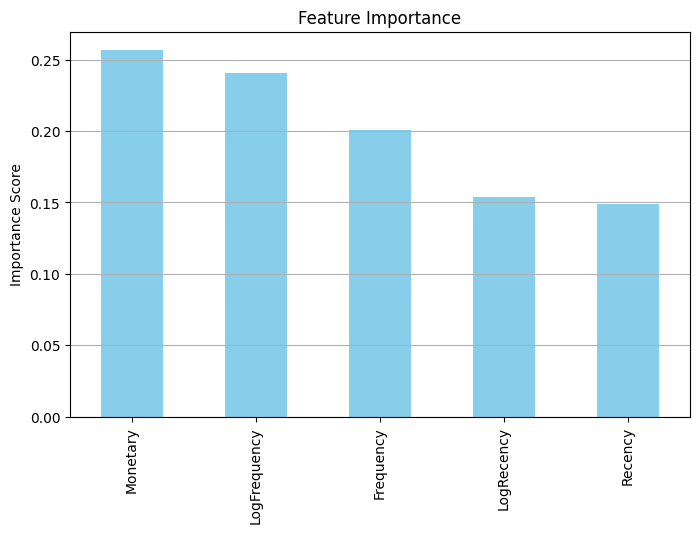

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar", color="skyblue")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.grid(axis="y")
plt.show()

In [54]:
result = pd.DataFrame({
    "Actual CLV": y_test,
    "Predicted CLV": prediction})

result.head(10)

,Actual CLV,Predicted CLV
3020,2.287410,2.365845
221,12.039811,11.677404
2226,144.995769,153.520125
1635,141.696000,152.456740
3453,456.017143,388.012646
920,1.544643,4.882460
259,64.016000,63.709426
216,79.416562,81.383392
1692,49.131795,50.636746
1055,651.666667,659.070313


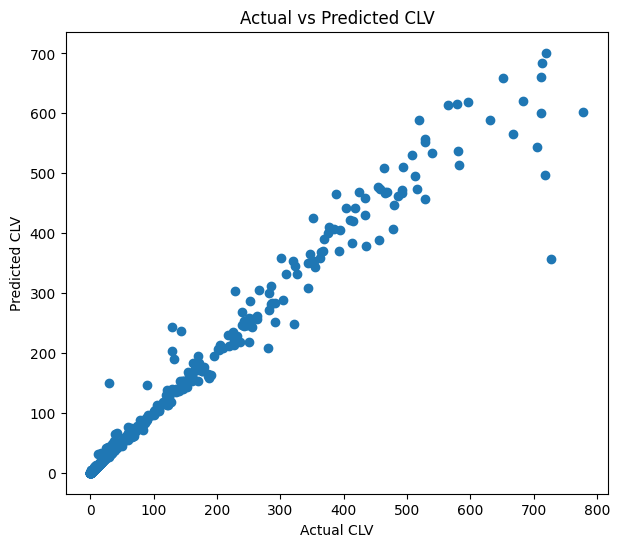

In [55]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
plt.scatter(y_test, prediction)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")
plt.show()

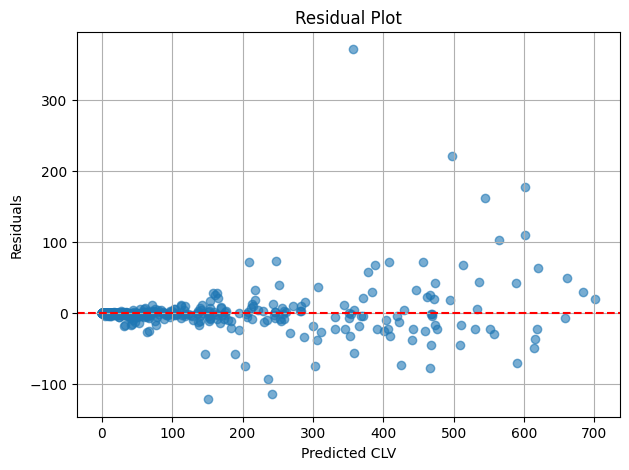

In [56]:
#Residual Plot
import matplotlib.pyplot as plt

residuals = y_test - prediction

plt.figure(figsize=(7,5))

plt.scatter(prediction, residuals, alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted CLV")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [57]:
print(rfm["CLV"].describe())

count    3564.000000
mean       87.699353
std       154.327159
min         0.008240
25%         2.883529
50%        16.553558
75%        91.253967
max       780.186000
Name: CLV, dtype: float64


In [58]:
import pandas as pd
import numpy as np

# User Input
recency = 10
frequency = 15
monetary = 25000   # Total amount spent by customer

# Create New Customer Features
new_customer = pd.DataFrame({
    "Recency": [recency],
    "Frequency": [frequency],
    "Monetary": [monetary],
    "LogFrequency": [np.log1p(frequency)],
    "LogRecency": [np.log1p(recency)]
})

# Predict CLV
predicted_clv = model.predict(new_customer)

print(f"Predicted Customer Lifetime Value (CLV): {predicted_clv[0]:.2f}")

Predicted Customer Lifetime Value (CLV): 743.03


In [59]:
print(rfm["CLV"].describe())

count    3564.000000
mean       87.699353
std       154.327159
min         0.008240
25%         2.883529
50%        16.553558
75%        91.253967
max       780.186000
Name: CLV, dtype: float64


In [60]:
##Dashboard (Streamlit)
#Save Model
import joblib
joblib.dump(model, "clv_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [61]:
#Save RFM Dataset
rfm.to_csv("rfm.csv", index=False)

In [62]:
##Dashboard Section
#Dashboard Heading
print("="*60)
print("E-Commerce Customer Dashboard")
print("="*60)

E-Commerce Customer Dashboard


In [63]:
#Business Summary
print("Total Customers :", len(rfm))
print("Average CLV :", round(rfm["CLV"].mean(),2))
print("Maximum CLV :", round(rfm["CLV"].max(),2))
print("Minimum CLV :", round(rfm["CLV"].min(),2))

Total Customers : 3564
Average CLV : 87.7
Maximum CLV : 780.19
Minimum CLV : 0.01


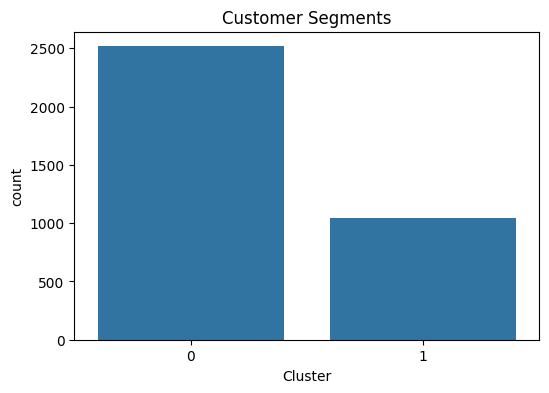

In [64]:
#Cluster Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(
    data=rfm,
    x="Cluster")
plt.title("Customer Segments")
plt.show()

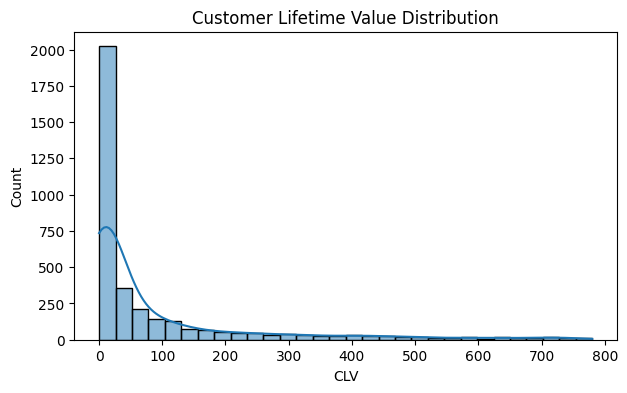

In [65]:
#CLV Distribution
plt.figure(figsize=(7,4))
sns.histplot(
    rfm["CLV"],
    bins=30,
    kde=True)
plt.title("Customer Lifetime Value Distribution")
plt.show()

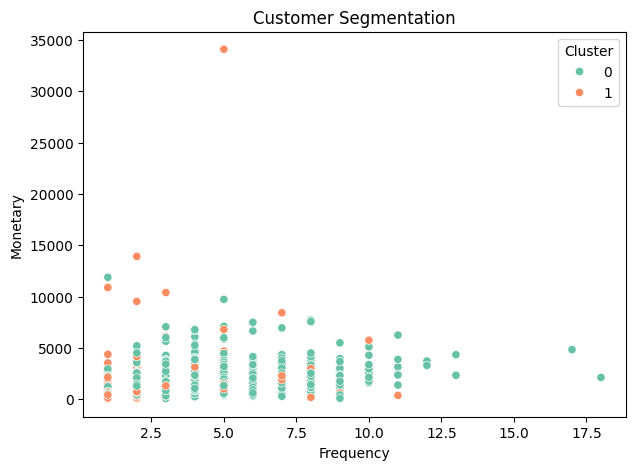

In [66]:
#Customer Segmentation
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2")
plt.title("Customer Segmentation")
plt.show()

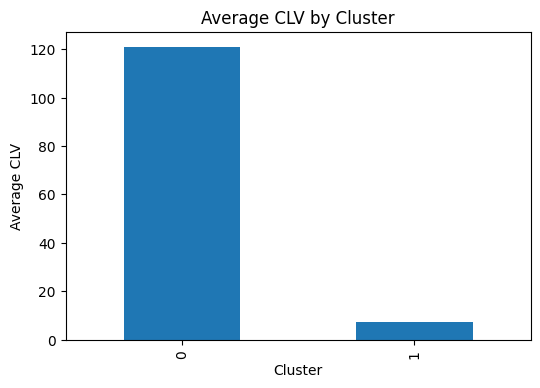

In [67]:
#Average CLV by Cluster
cluster_clv = rfm.groupby("Cluster")["CLV"].mean()
cluster_clv.plot(
    kind="bar",
    figsize=(6,4))
plt.title("Average CLV by Cluster")
plt.ylabel("Average CLV")
plt.show()

In [68]:
#Top 10 Customers
rfm.sort_values(
    by="CLV",
    ascending=False
).head(10)

,CustomerID,Frequency,Monetary,Recency,Cluster,CustomerSegment,AvgOrderValue,CustomerLifeSpan,PurchaseRate,CLV,LogFrequency,LogRecency
1688,14710.0,9,1300.31,14,0,At Risk Customers,144.478889,15,0.600000,780.186000,2.302585,2.708050
466,13037.0,9,3033.88,34,0,At Risk Customers,337.097778,35,0.257143,780.140571,2.302585,3.555348
4054,17929.0,8,2239.10,22,0,At Risk Customers,279.887500,23,0.347826,778.817391,2.197225,3.135494
4158,18069.0,6,2455.68,18,0,At Risk Customers,409.280000,19,0.315789,775.477895,1.945910,2.944439
1879,14963.0,7,1651.23,14,0,At Risk Customers,235.890000,15,0.466667,770.574000,2.079442,2.708050
1035,13823.0,5,2445.79,15,0,At Risk Customers,489.158000,16,0.312500,764.309375,1.791759,2.772589
66,12435.0,4,6096.04,31,0,At Risk Customers,1524.010000,32,0.125000,762.005000,1.609438,3.465736
1846,14918.0,7,4345.66,39,0,At Risk Customers,620.808571,40,0.175000,760.490500,2.079442,3.688879
336,12863.0,5,2271.35,14,0,At Risk Customers,454.270000,15,0.333333,757.116667,1.791759,2.708050
409,12967.0,2,2646.02,6,0,At Risk Customers,1323.010000,7,0.285714,756.005714,1.098612,1.945910


In [69]:
#: Cluster Summary
rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean",
    "CLV":"mean"})

,Recency,Frequency,Monetary,CLV
Cluster,,,,
0,50.467620,2.922527,989.349905,121.083661
1,241.976122,1.659981,593.540319,7.443092


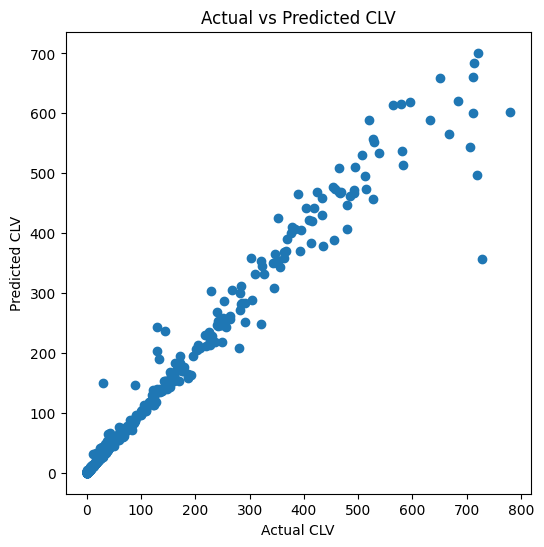

In [70]:
plt.figure(figsize=(6,6))
plt.scatter(
    y_test,
    prediction)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")
plt.show()

In [71]:
#Feature Importance
importance = pd.DataFrame({
     "Feature":X.columns,
     "Importance":model.feature_importances_})
importance.sort_values(
    by="Importance",
    ascending=False)

,Feature,Importance
2,Monetary,0.256719
3,LogFrequency,0.240411
1,Frequency,0.200707
4,LogRecency,0.153621
0,Recency,0.148542


In [72]:
import pandas as pd
import numpy as np

# Customer Input
recency = 10
frequency = 5
monetary = 1200

# Log Features
log_frequency = np.log1p(frequency)
log_recency = np.log1p(recency)

# Create DataFrame (same columns as X)
new_customer = pd.DataFrame({
    "Recency": [recency],
    "Frequency": [frequency],
    "Monetary": [monetary],
    "LogFrequency": [log_frequency],
    "LogRecency": [log_recency]
})

# Predict CLV
predicted_clv = model.predict(new_customer)

print(f"Predicted Customer Lifetime Value (CLV): {predicted_clv[0]:.2f}")

Predicted Customer Lifetime Value (CLV): 549.63


In [73]:
print(X.columns)
print(new_customer.columns)

Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')
Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')


In [74]:
print("========== BUSINESS RECOMMENDATIONS ==========\n")

print("High Value Customers")
print("- Premium Offers")
print("- Loyalty Rewards")
print("- Exclusive Discounts\n")

print("Regular Customers")
print("- Personalized Recommendations")
print("- Email Marketing")
print("- Cross Selling\n")

print("At Risk Customers")
print("- Win-back Campaigns")
print("- Coupons")
print("- Reminder Emails")

========== BUSINESS RECOMMENDATIONS ==========

High Value Customers
- Premium Offers
- Loyalty Rewards
- Exclusive Discounts

Regular Customers
- Personalized Recommendations
- Email Marketing
- Cross Selling

At Risk Customers
- Win-back Campaigns
- Coupons
- Reminder Emails


In [75]:
import joblib

joblib.dump(model, "clv_model.pkl")

['clv_model.pkl']

In [76]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)

print("Cross-validation RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())


Cross-validation RMSE scores: [27.92587756 28.70174093 37.16158629 24.15290388 20.79888701]
Average RMSE: 27.748199133243453


In [77]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 81.0 MB/s eta 0:00:00


In [78]:
import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load("clv_model.pkl")

st.set_page_config(
    page_title="Customer Lifetime Value Prediction",
    page_icon="🛒",
    layout="centered"
)

st.title("🛍️ E-Commerce Customer Lifetime Value Prediction")
st.write("Enter customer details to predict Customer Lifetime Value (CLV).")

# Input fields
recency = st.number_input("Recency (Days)", min_value=0, value=30)
frequency = st.number_input("Frequency", min_value=0, value=5)
monetary = st.number_input("Monetary Value", min_value=0.0, value=5000.0)

# Predict
if st.button("Predict CLV"):
    input_df = pd.DataFrame({
        "Recency": [recency],
        "Frequency": [frequency],
        "Monetary": [monetary],
        "LogFrequency": [np.log1p(frequency)],
        "LogRecency": [np.log1p(recency)]
    })

    prediction = model.predict(input_df)[0]

    st.success(f"Predicted Customer Lifetime Value: ₹ {prediction:,.2f}")

2026-08-07 06:56:42.724 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-07 06:56:42.726 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-07 06:56:43.028 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-07 06:56:43.029 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-07 06:56:43.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-07 06:56:43.032 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-07 06:56:43.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [79]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load trained model
model = joblib.load("clv_model.pkl")

st.set_page_config(
    page_title="Customer Lifetime Value Prediction",
    page_icon="🛒",
    layout="centered"
)

st.title("🛍️ E-Commerce Customer Lifetime Value Prediction")
st.write("Enter customer details to predict Customer Lifetime Value (CLV).")

# Input fields
recency = st.number_input("Recency (Days)", min_value=0, value=30)
frequency = st.number_input("Frequency", min_value=0, value=5)
monetary = st.number_input("Monetary Value", min_value=0.0, value=5000.0)

# Predict
if st.button("Predict CLV"):
    input_df = pd.DataFrame({
        "Recency": [recency],
        "Frequency": [frequency],
        "Monetary": [monetary],
        "LogFrequency": [np.log1p(frequency)],
        "LogRecency": [np.log1p(recency)]
    })

    prediction = model.predict(input_df)[0]

    st.success(f"Predicted Customer Lifetime Value: ₹ {prediction:,.2f}")

Writing app.py


In [80]:
!pip install ngrok
!streamlit run app.py &>/dev/null&  # Run Streamlit in the background
from ngrok import ngrok

# Terminate any previous ngrok tunnels
ngrok.kill()

# Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok authentication token
# You can get one from your ngrok dashboard: https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_AUTH_TOKEN = "YOUR_NGROK_AUTH_TOKEN" # <--- IMPORTANT: Update this line
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Open a ngrok tunnel to the Streamlit port (default 8501)
public_url = ngrok.connect(addr='8501', proto='http')
print(f"Streamlit App URL: {public_url}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 39.4 MB/s eta 0:00:00
Streamlit App URL: <Task pending name='Task-5' coro=<wrap() running at ngrok_wrapper:6>>


In [ ]:
import joblib

# model ko compress karke save karo
joblib.dump(model, "clv_model.pkl", compress=9)

In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
openpyxl